In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import (
    zscore,
    jarque_bera,
    normaltest,
    ttest_1samp,
    spearmanr
)

In [2]:
processed_data = pd.read_csv(
    "../data/processed/spy_features.csv",
    index_col=0,
    parse_dates=True
)

Part 1：z-score

In [7]:
returns = processed_data["ret_1d"].dropna()

z = zscore(returns)

z.head(10)

Date
2016-02-02   -1.649490
2016-02-03    0.473465
2016-02-04    0.082167
2016-02-05   -1.740390
2016-02-08   -1.246291
2016-02-09   -0.051697
2016-02-10   -0.132713
2016-02-11   -1.206285
2016-02-12    1.765962
2016-02-16    1.435484
Name: ret_1d, dtype: float64

Part 2：do returns follow Normal distribution？

In [8]:
ret = processed_data["ret_1d"].dropna()

print("Mean:", ret.mean())
print("Std:", ret.std())
print("Skewness:", stats.skew(ret))
print("Kurtosis:", stats.kurtosis(ret))

Mean: 0.0006386393499227271
Std: 0.01131532667869677
Skewness: -0.32394648465658404
Kurtosis: 14.981199631036457


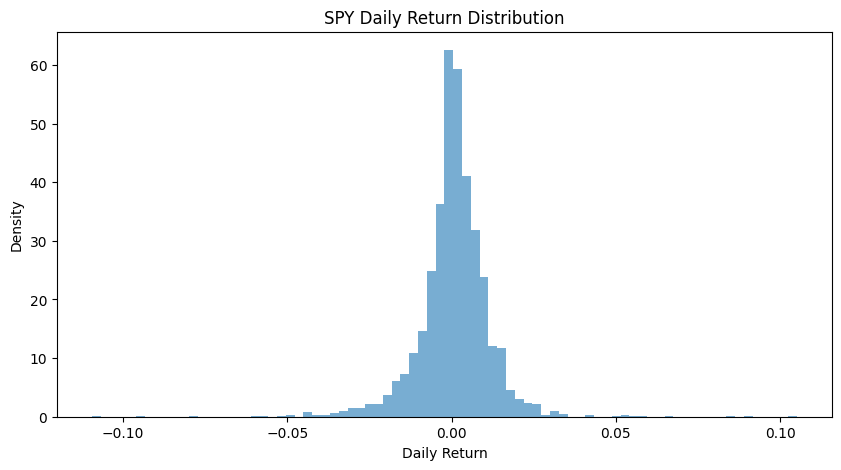

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(
    ret,
    bins=80,
    density=True,
    alpha=0.6
)

plt.title("SPY Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Density")

plt.show()

Jarque-Bera test

In [10]:
jb = jarque_bera(ret)

print(jb)

SignificanceResult(statistic=np.float64(23356.928185743258), pvalue=np.float64(0.0))


In [11]:
jb.statistic, jb.pvalue

(np.float64(23356.928185743258), np.float64(0.0))

normal test

In [12]:
nt = normaltest(ret)

print(nt)

NormaltestResult(statistic=np.float64(590.2883571102642), pvalue=np.float64(6.61472643262706e-129))


In [13]:
nt.statistic, nt.pvalue

(np.float64(590.2883571102642), np.float64(6.61472643262706e-129))

Part 3：t-test

In [14]:
oversold = processed_data.loc[
    processed_data["zscore_20d"] < -2,
    "next_return"
].dropna()

In [15]:
len(oversold), oversold.mean()

(109, np.float64(0.004191799957281632))

In [16]:
result = ttest_1samp(
    oversold,
    popmean=0
)

print(result)

TtestResult(statistic=np.float64(2.107251281851894), pvalue=np.float64(0.03741071353504021), df=np.int64(108))


In [17]:
result = ttest_1samp(
    oversold,
    popmean=0,
    alternative="greater"
)

print(result)

TtestResult(statistic=np.float64(2.107251281851894), pvalue=np.float64(0.018705356767520106), df=np.int64(108))


In [18]:
overbought = processed_data.loc[
    processed_data["zscore_20d"] > 2,
    "next_return"
].dropna()

In [20]:
result_overbought = ttest_1samp(
    overbought,
    popmean=0,
    alternative="less"
)

print(result)

TtestResult(statistic=np.float64(2.107251281851894), pvalue=np.float64(0.018705356767520106), df=np.int64(108))


Part 4：Spearman correlation

In [21]:
processed_data.corr()

,ret_1d,ret_5d,ret_20d,vol_20d,ma_20_dist,zscore_20d,volume_zscore_20d,ret_lag1,ret_lag2,ret_lag3,next_return,target_up
ret_1d,1.000000,0.411434,0.206965,0.021544,0.368776,0.365836,-0.254440,-0.134236,0.078532,-0.030120,-0.134307,-0.033146
ret_5d,0.411434,1.000000,0.466276,-0.023996,0.749509,0.681709,-0.392046,0.381385,0.436996,0.385498,-0.051197,-0.021013
ret_20d,0.206965,0.466276,1.000000,-0.396914,0.842500,0.664150,-0.205505,0.183726,0.190043,0.191270,-0.038643,-0.002641
vol_20d,0.021544,-0.023996,-0.396914,1.000000,-0.238613,-0.228872,-0.081525,0.005939,-0.005779,-0.016979,0.033015,-0.005052
ma_20_dist,0.368776,0.749509,0.842500,-0.238613,1.000000,0.819387,-0.369477,0.299176,0.315845,0.286843,-0.051909,-0.009199
zscore_20d,0.365836,0.681709,0.664150,-0.228872,0.819387,1.000000,-0.413524,0.304413,0.279646,0.235889,-0.024024,-0.003546
volume_zscore_20d,-0.254440,-0.392046,-0.205505,-0.081525,-0.369477,-0.413524,1.000000,-0.193269,-0.144141,-0.105585,-0.014993,-0.005562
ret_lag1,-0.134236,0.381385,0.183726,0.005939,0.299176,0.304413,-0.193269,1.000000,-0.134221,0.078511,0.080129,0.033669
ret_lag2,0.078532,0.436996,0.190043,-0.005779,0.315845,0.279646,-0.144141,-0.134221,1.000000,-0.133773,-0.029849,-0.001119
ret_lag3,-0.030120,0.385498,0.191270,-0.016979,0.286843,0.235889,-0.105585,0.078511,-0.133773,1.000000,-0.064260,-0.021824


In [22]:
rho, pvalue = spearmanr(
    processed_data["zscore_20d"],
    processed_data["next_return"],
    nan_policy="omit"
)

print("Spearman rho:", rho)
print("p-value:", pvalue)

Spearman rho: -0.046300076927164535
p-value: 0.02078644902518153


In [23]:
features = [
    "ret_1d",
    "ret_5d",
    "ret_20d",
    "vol_20d",
    "zscore_20d",
    "volume_zscore_20d"
]

for feature in features:

    rho, p = spearmanr(
        processed_data[feature],
        processed_data["next_return"],
        nan_policy="omit"
    )

    print(
        f"{feature:20s} "
        f"rho={rho:.4f}, "
        f"p={p:.4f}"
    )

ret_1d               rho=-0.0342, p=0.0881
ret_5d               rho=-0.0445, p=0.0262
ret_20d              rho=-0.0260, p=0.1942
vol_20d              rho=0.0362, p=0.0708
zscore_20d           rho=-0.0463, p=0.0208
volume_zscore_20d    rho=0.0287, p=0.1517


Part 5：Pearson vs Spearman

In [ ]:
pearson = processed_data[
    ["zscore_20d", "next_return"]
].corr().iloc[0, 1]

spearman, _ = spearmanr(
    processed_data["zscore_20d"],
    processed_data["next_return"],
    nan_policy="omit"
)

print("Pearson:", pearson) #linearity
print("Spearman:", spearman) #ranking

Pearson: -0.0240242515006019
Spearman: -0.046300076927164535


Part 6：conditional return table

In [25]:
bins = [
    -np.inf,
    -2,
    -1,
    0,
    1,
    2,
    np.inf
]

labels = [
    "< -2",
    "-2 to -1",
    "-1 to 0",
    "0 to 1",
    "1 to 2",
    "> 2"
]

processed_data["z_bucket"] = pd.cut(
    processed_data["zscore_20d"],
    bins=bins,
    labels=labels
)

In [26]:
bucket_stats = (
    processed_data
    .groupby("z_bucket", observed=False)["next_return"]
    .agg(["mean", "median", "std", "count"])
)

bucket_stats

,mean,median,std,count
z_bucket,,,,
< -2,0.004192,0.002353,0.020768,109
-2 to -1,-0.000507,0.000437,0.018504,281
-1 to 0,0.000855,0.001074,0.013539,355
0 to 1,0.000835,0.001309,0.009527,610
1 to 2,0.000487,0.000531,0.007018,1015
> 2,-0.000148,0.000287,0.005959,123


Part 7：draw bucket mean return

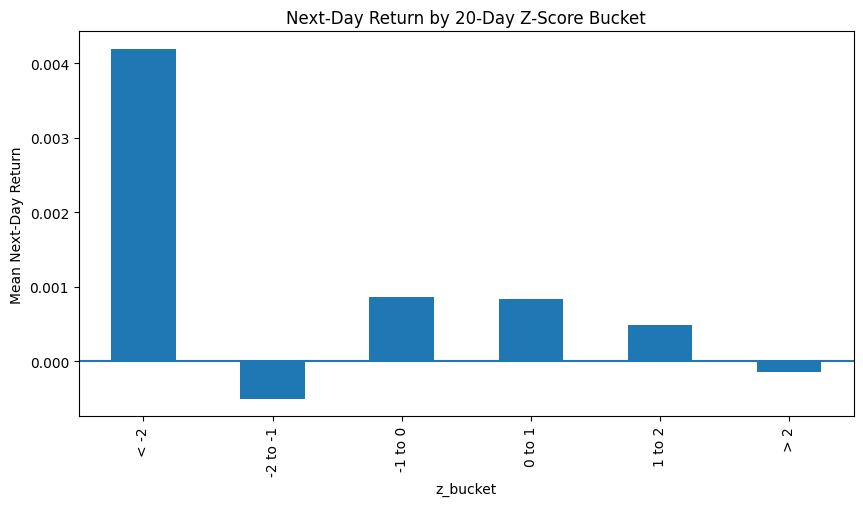

In [27]:
bucket_stats["mean"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.axhline(0)

plt.ylabel("Mean Next-Day Return")
plt.title(
    "Next-Day Return by 20-Day Z-Score Bucket"
)

plt.show()

Part 8：distribution fitting

In [28]:
mu, sigma = stats.norm.fit(ret)

print(mu, sigma)

0.0006386393499227271 0.011313057031360992


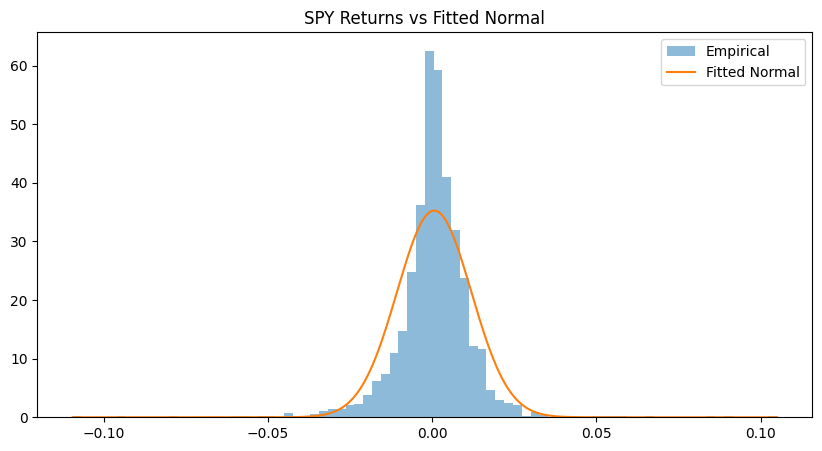

In [29]:
x = np.linspace(
    ret.min(),
    ret.max(),
    500
)

pdf = stats.norm.pdf(
    x,
    loc=mu,
    scale=sigma
)

plt.figure(figsize=(10, 5))

plt.hist(
    ret,
    bins=80,
    density=True,
    alpha=0.5,
    label="Empirical"
)

plt.plot(
    x,
    pdf,
    label="Fitted Normal"
)

plt.legend()
plt.title("SPY Returns vs Fitted Normal")

plt.show()